<div dir="rtl" style="text-align:right">

# תרגול 13  — Autoencoder, RNN ו־LSTM


```text
Autoencoder
→ Reconstruction
→ Latent Space

Time Series
→ Sliding Windows
→ RNN
→ LSTM
→ Forecast Comparison
```

</div>

<div dir="rtl" style="text-align:right">

## 0. Setup

</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)
torch.set_num_threads(1)

if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("Device:", device)

Device: mps


In [2]:
def draw_autoencoder_architecture():
    plt.figure(figsize=(10, 3))
    plt.axis("off")

    x_positions = [0.08, 0.30, 0.50, 0.70, 0.92]
    labels = [
        "Input\n64 pixels",
        "Encoder\n64 → 32",
        "Latent\n2 values",
        "Decoder\n2 → 32 → 64",
        "Reconstruction\n64 pixels"
    ]

    for x, label in zip(x_positions, labels):
        plt.text(
            x,
            0.5,
            label,
            ha="center",
            va="center",
            bbox={"boxstyle": "round,pad=0.5"}
        )

    for left, right in zip(x_positions[:-1], x_positions[1:]):
        plt.annotate(
            "",
            xy=(right - 0.07, 0.5),
            xytext=(left + 0.07, 0.5),
            arrowprops={"arrowstyle": "->"}
        )

    plt.title("Autoencoder Architecture")
    plt.show()


def draw_rnn_unrolling(n_steps=5):
    plt.figure(figsize=(11, 4))
    plt.axis("off")

    x_positions = np.linspace(0.10, 0.90, n_steps)

    for index, x in enumerate(x_positions):
        plt.text(
            x,
            0.55,
            f"RNN Cell\nstep {index + 1}",
            ha="center",
            va="center",
            bbox={"boxstyle": "round,pad=0.4"}
        )

        plt.text(
            x,
            0.18,
            f"x{index + 1}",
            ha="center",
            va="center"
        )

        plt.annotate(
            "",
            xy=(x, 0.44),
            xytext=(x, 0.25),
            arrowprops={"arrowstyle": "->"}
        )

        if index < n_steps - 1:
            next_x = x_positions[index + 1]
            plt.annotate(
                "",
                xy=(next_x - 0.07, 0.55),
                xytext=(x + 0.07, 0.55),
                arrowprops={"arrowstyle": "->"}
            )
            plt.text(
                (x + next_x) / 2,
                0.64,
                f"h{index + 1}",
                ha="center"
            )

    plt.title("RNN Unrolled Through Time — Same Weights at Every Step")
    plt.show()


def draw_lstm_gate_diagram():
    plt.figure(figsize=(11, 5))
    plt.axis("off")

    plt.text(
        0.10,
        0.75,
        "Previous\ncell state c(t-1)",
        ha="center",
        va="center",
        bbox={"boxstyle": "round,pad=0.4"}
    )

    plt.text(
        0.30,
        0.75,
        "Forget gate\nwhat to keep?",
        ha="center",
        va="center",
        bbox={"boxstyle": "round,pad=0.4"}
    )

    plt.text(
        0.50,
        0.45,
        "Input gate\nwhat to add?",
        ha="center",
        va="center",
        bbox={"boxstyle": "round,pad=0.4"}
    )

    plt.text(
        0.70,
        0.75,
        "New cell state\nc(t)",
        ha="center",
        va="center",
        bbox={"boxstyle": "round,pad=0.4"}
    )

    plt.text(
        0.88,
        0.45,
        "Output gate\nwhat to expose?",
        ha="center",
        va="center",
        bbox={"boxstyle": "round,pad=0.4"}
    )

    plt.text(
        0.88,
        0.15,
        "Hidden state\nh(t)",
        ha="center",
        va="center",
        bbox={"boxstyle": "round,pad=0.4"}
    )

    plt.text(
        0.30,
        0.20,
        "Current input x(t)\n+\nprevious hidden h(t-1)",
        ha="center",
        va="center",
        bbox={"boxstyle": "round,pad=0.4"}
    )

    arrows = [
        ((0.16, 0.75), (0.24, 0.75)),
        ((0.36, 0.75), (0.64, 0.75)),
        ((0.37, 0.27), (0.46, 0.40)),
        ((0.56, 0.45), (0.67, 0.70)),
        ((0.76, 0.72), (0.84, 0.50)),
        ((0.88, 0.37), (0.88, 0.22))
    ]

    for start, end in arrows:
        plt.annotate(
            "",
            xy=end,
            xytext=start,
            arrowprops={"arrowstyle": "->"}
        )

    plt.title("LSTM Information Flow")
    plt.show()


def draw_lstm_shape_flow():
    plt.figure(figsize=(11, 3.5))
    plt.axis("off")

    labels = [
        ("Input", "[B, T, 1]", 0.10),
        ("LSTM", "hidden size H", 0.36),
        ("Output", "[B, T, H]", 0.62),
        ("Final states", "h_n, c_n:\n[1, B, H]", 0.88)
    ]

    for title, shape, x in labels:
        plt.text(
            x,
            0.55,
            f"{title}\n{shape}",
            ha="center",
            va="center",
            bbox={"boxstyle": "round,pad=0.5"}
        )

    for left, right in zip(
        [item[2] for item in labels[:-1]],
        [item[2] for item in labels[1:]]
    ):
        plt.annotate(
            "",
            xy=(right - 0.08, 0.55),
            xytext=(left + 0.08, 0.55),
            arrowprops={"arrowstyle": "->"}
        )

    plt.title("LSTM Tensor Shapes")
    plt.show()

<div dir="rtl" style="text-align:right">

# חלק א׳ — Autoencoder

Autoencoder מקבל קלט ומנסה לשחזר אותו:

```text
Input → Encoder → Latent Space → Decoder → Reconstruction
```

הקלט עצמו הוא גם ה־target.

</div>

In [3]:
digits = load_digits()

images = digits.images.astype(np.float32) / 16.0
labels = digits.target

X_train_np, X_test_np, y_train_labels, y_test_labels = train_test_split(
    images.reshape(-1, 64),
    labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

X_train_ae = torch.tensor(
    X_train_np,
    dtype=torch.float32,
    device=device
)

X_test_ae = torch.tensor(
    X_test_np,
    dtype=torch.float32,
    device=device
)

print("All images:", images.shape)
print("Train tensor:", X_train_ae.shape)
print("Test tensor:", X_test_ae.shape)

All images: (1797, 8, 8)
Train tensor: torch.Size([1437, 64])
Test tensor: torch.Size([360, 64])


<div dir="rtl" style="text-align:right">

## תרגיל 1 — תמונה כמטריצת פיקסלים

בחרו תמונה אחת והציגו:

1. את התמונה.
2. Heatmap עם ערכי הפיקסלים.
3. את ה־shape של התמונה לאחר הפיכה ל־Tensor.

</div>

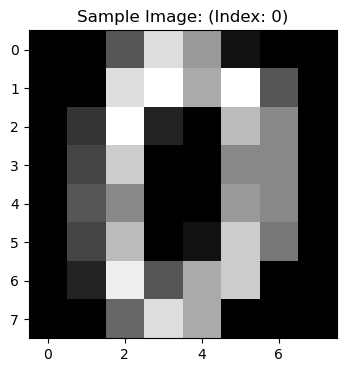

Labels [sample_index]: 0
Sample tensor shape: torch.Size([1, 1, 8, 8])


In [6]:
# TODO:
sample_index = 0
sample_image = images[sample_index]
# הציגו תמונה
plt.figure(figsize=(4, 4))
plt.imshow(sample_image, cmap="gray")
plt.title(f"Sample Image: (Index: {sample_index})")
plt.show()
print(f"Labels [sample_index]: {labels[sample_index]}")
# הציגו heatmap עם ערכים
# צרו tensor עם shape [1, 1, 8, 8]
sample_tensor = torch.tensor(sample_image, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
print("Sample tensor shape:", sample_tensor.shape)

<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
sample_index = 0
sample_image = images[sample_index]

plt.figure(figsize=(4, 4))
plt.imshow(sample_image, cmap="gray")
plt.title(f"Digit: {labels[sample_index]}")
plt.axis("off")
plt.show()

plt.figure(figsize=(5, 5))
plt.imshow(sample_image, cmap="gray")

for row in range(8):
    for col in range(8):
        plt.text(
            col,
            row,
            f"{sample_image[row, col]:.1f}",
            ha="center",
            va="center"
        )

plt.title("Image as a Pixel Matrix")
plt.colorbar()
plt.show()

sample_tensor = torch.tensor(
    sample_image,
    dtype=torch.float32
).unsqueeze(0).unsqueeze(0)

print("Image tensor shape:", sample_tensor.shape)
```

</details>

<div dir="rtl" style="text-align:right">

## Autoencoder Architecture

</div>

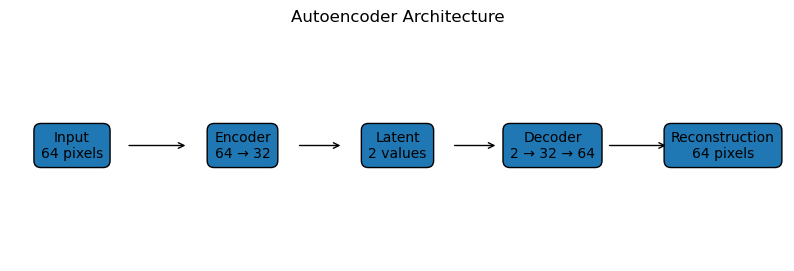

In [7]:
draw_autoencoder_architecture()

In [8]:
class DigitAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

        self.decoder = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction, latent

<div dir="rtl" style="text-align:right">

## אימון ה־Autoencoder

נשתמש ב־MSE בין התמונה המקורית לבין התמונה המשוחזרת.

</div>

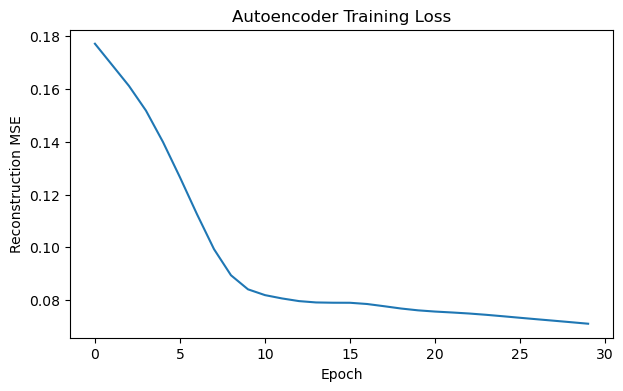

Initial loss: 0.17716631293296814
Final loss: 0.07102016359567642


In [9]:
torch.manual_seed(42)

autoencoder = DigitAutoencoder().to(device)

autoencoder_optimizer = torch.optim.Adam(
    autoencoder.parameters(),
    lr=0.01
)

reconstruction_loss_fn = nn.MSELoss()

autoencoder_losses = []

for epoch in range(30):
    autoencoder.train()

    reconstruction, latent = autoencoder(X_train_ae)

    loss = reconstruction_loss_fn(
        reconstruction,
        X_train_ae
    )

    autoencoder_optimizer.zero_grad()
    loss.backward()
    autoencoder_optimizer.step()

    autoencoder_losses.append(loss.item())

plt.figure(figsize=(7, 4))
plt.plot(autoencoder_losses)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction MSE")
plt.title("Autoencoder Training Loss")
plt.show()

print("Initial loss:", autoencoder_losses[0])
print("Final loss:", autoencoder_losses[-1])

<div dir="rtl" style="text-align:right">

## תרגיל 2 — Reconstruction ו־Error Map

בחרו תמונה מ־test והציגו בגרפים נפרדים:

1. Original image.
2. Reconstructed image.
3. Absolute reconstruction error.

</div>

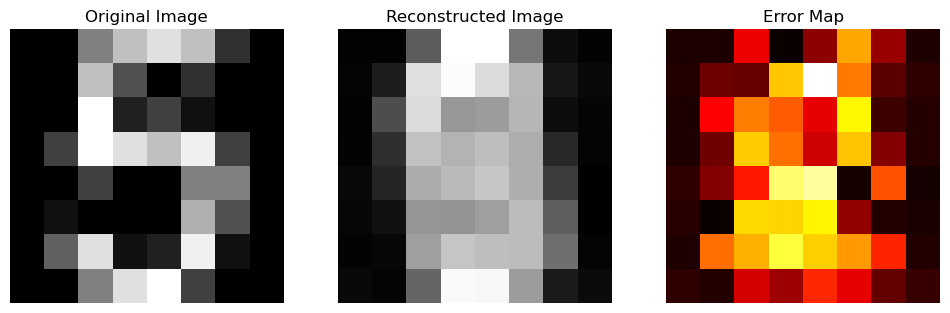

In [11]:
# TODO:
# העבירו את X_test_ae דרך autoencoder
# בחרו sample
# הציגו original, reconstruction, error map

autoencoder.eval()
with torch.no_grad():
    reconstruction, latent = autoencoder(X_test_ae)

    sample_index = 0
    original_image = X_test_ae[sample_index].cpu().numpy().reshape(8, 8)
    reconstructed_image = reconstruction[sample_index].cpu().numpy().reshape(8, 8)
    error_map = np.abs(original_image - reconstructed_image)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(original_image, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(reconstructed_image, cmap="gray")
    plt.title("Reconstructed Image")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(error_map, cmap="hot")
    plt.title("Error Map")
    plt.axis("off")

    plt.show()

<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
autoencoder.eval()

with torch.no_grad():
    reconstructed_test, latent_test = autoencoder(
        X_test_ae
    )

sample_index = 10

original = (
    X_test_ae[sample_index]
    .detach()
    .cpu()
    .numpy()
    .reshape(8, 8)
)

reconstructed = (
    reconstructed_test[sample_index]
    .detach()
    .cpu()
    .numpy()
    .reshape(8, 8)
)

error_map = np.abs(
    original - reconstructed
)

plt.figure(figsize=(4, 4))
plt.imshow(original, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

plt.figure(figsize=(4, 4))
plt.imshow(reconstructed, cmap="gray")
plt.title("Reconstructed Image")
plt.axis("off")
plt.show()

plt.figure(figsize=(4, 4))
plt.imshow(error_map)
plt.title("Absolute Reconstruction Error")
plt.colorbar()
plt.show()
```

</details>

<div dir="rtl" style="text-align:right">

## תרגיל 3 — Latent Space

הציגו את הייצוג הדו־ממדי של כל תמונות ה־test.

צבעו לפי digit label.

</div>

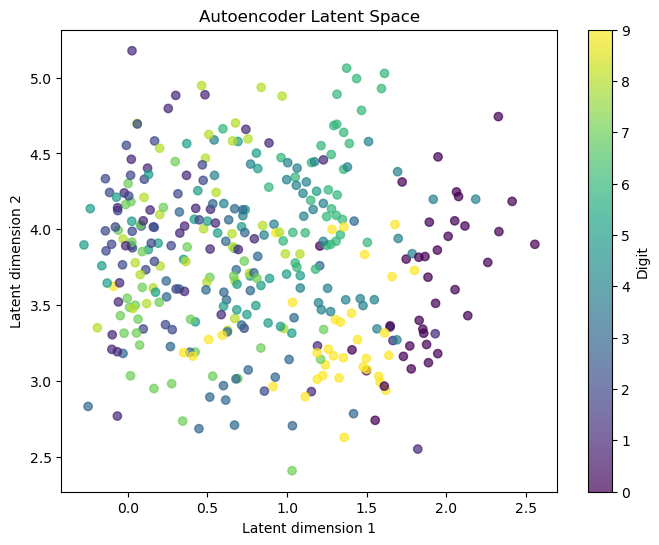

In [12]:
# TODO:
# latent_np = ...
# scatter of latent dimension 1 vs 2


autoencoder.eval()

with torch.no_grad():
    _, latent_test = autoencoder(X_test_ae)

latent_np = (
    latent_test
    .detach()
    .cpu()
    .numpy()
)

plt.figure(figsize=(8, 6))
plt.scatter(
    latent_np[:, 0],
    latent_np[:, 1],
    c=y_test_labels,
    alpha=0.7
)
plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.title("Autoencoder Latent Space")
plt.colorbar(label="Digit")
plt.show()


<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
autoencoder.eval()

with torch.no_grad():
    _, latent_test = autoencoder(X_test_ae)

latent_np = (
    latent_test
    .detach()
    .cpu()
    .numpy()
)

plt.figure(figsize=(8, 6))
plt.scatter(
    latent_np[:, 0],
    latent_np[:, 1],
    c=y_test_labels,
    alpha=0.7
)
plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.title("Autoencoder Latent Space")
plt.colorbar(label="Digit")
plt.show()
```

</details>

<div dir="rtl" style="text-align:right">

# חלק ב׳ — סדרת זמן ו־Sliding Windows

</div>

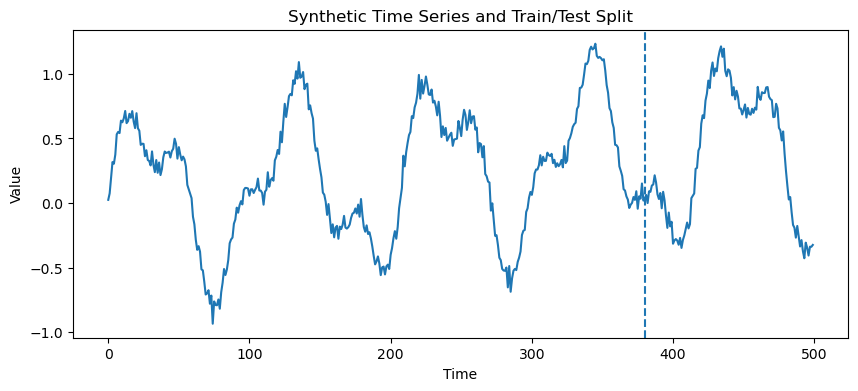

In [13]:
time = np.arange(500)

series = (
    0.6 * np.sin(0.06 * time)
    + 0.3 * np.sin(0.15 * time)
    + 0.001 * time
    + np.random.normal(
        0,
        0.05,
        size=len(time)
    )
).astype(np.float32)

split_index = 380
lookback = 30

plt.figure(figsize=(10, 4))
plt.plot(time, series)
plt.axvline(split_index, linestyle="--")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Synthetic Time Series and Train/Test Split")
plt.show()

In [14]:
def make_windows(values, lookback):
    X_windows = []
    y_targets = []

    for index in range(len(values) - lookback):
        X_windows.append(
            values[index:index + lookback]
        )
        y_targets.append(
            values[index + lookback]
        )

    return (
        np.array(X_windows, dtype=np.float32),
        np.array(y_targets, dtype=np.float32)
    )


train_values = series[:split_index]
test_values = series[split_index - lookback:]

train_mean = train_values.mean()
train_std = train_values.std()

train_scaled = (
    train_values - train_mean
) / train_std

test_scaled = (
    test_values - train_mean
) / train_std

X_train_seq_np, y_train_seq_np = make_windows(
    train_scaled,
    lookback
)

X_test_seq_np, y_test_seq_np = make_windows(
    test_scaled,
    lookback
)

X_train_seq = torch.tensor(
    X_train_seq_np,
    dtype=torch.float32,
    device=device
).unsqueeze(-1)

y_train_seq = torch.tensor(
    y_train_seq_np,
    dtype=torch.float32,
    device=device
).unsqueeze(-1)

X_test_seq = torch.tensor(
    X_test_seq_np,
    dtype=torch.float32,
    device=device
).unsqueeze(-1)

y_test_seq = torch.tensor(
    y_test_seq_np,
    dtype=torch.float32,
    device=device
).unsqueeze(-1)

print("Train windows:", X_train_seq.shape)
print("Train targets:", y_train_seq.shape)
print("Test windows:", X_test_seq.shape)
print("Test targets:", y_test_seq.shape)

Train windows: torch.Size([350, 30, 1])
Train targets: torch.Size([350, 1])
Test windows: torch.Size([120, 30, 1])
Test targets: torch.Size([120, 1])


<div dir="rtl" style="text-align:right">

## תרגיל 4 — חלון קלט ו־Target

בחרו חלון אחד והציגו:

- את 30 ערכי הקלט.
- את ה־target הבא כנקודה נפרדת.

</div>

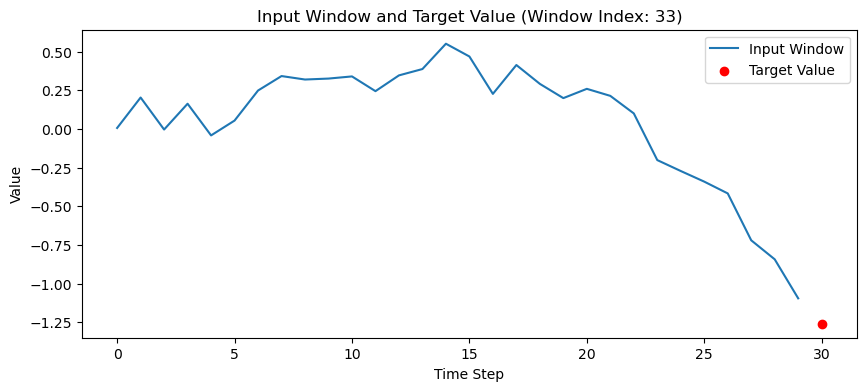

In [19]:
# TODO:
from sympy import plot


window_index = 33
window = (X_train_seq[window_index].cpu().numpy().squeeze(), y_train_seq[window_index].cpu().numpy().squeeze())
target = y_train_seq[window_index].cpu().numpy().squeeze()
plt.figure(figsize=(10, 4))
plt.plot(range(lookback), window[0], label="Input Window")
plt.scatter(lookback, target, color="red", label="Target Value")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.title(f"Input Window and Target Value (Window Index: {window_index})")
plt.legend()
plt.show()

<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
window_index = 40

window = (
    X_train_seq[window_index, :, 0]
    .detach()
    .cpu()
    .numpy()
)

target = (
    y_train_seq[window_index, 0]
    .item()
)

plt.figure(figsize=(8, 4))
plt.plot(
    range(lookback),
    window,
    marker="o",
    label="input window"
)
plt.scatter(
    [lookback],
    [target],
    marker="x",
    s=100,
    label="next-step target"
)
plt.xlabel("Position in sequence")
plt.ylabel("Scaled value")
plt.title("Input Window and Target")
plt.legend()
plt.show()
```

</details>

<div dir="rtl" style="text-align:right">

# חלק ג׳ — RNN

</div>

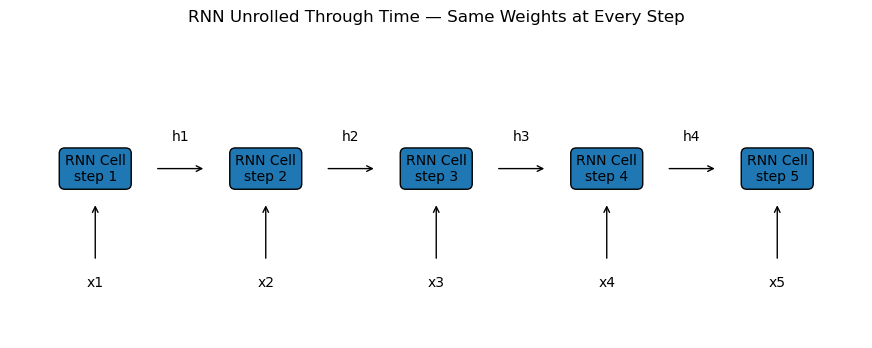

In [20]:
draw_rnn_unrolling()

In [21]:
class RNNForecaster(nn.Module):
    def __init__(self, hidden_size=16):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.output_layer = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x, return_sequence=False):
        output, h_n = self.rnn(x)
        final_hidden = h_n[-1]
        prediction = self.output_layer(final_hidden)

        if return_sequence:
            return prediction, output, h_n

        return prediction


class LSTMForecaster(nn.Module):
    def __init__(self, hidden_size=16):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.output_layer = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x, return_sequence=False):
        output, (h_n, c_n) = self.lstm(x)
        final_hidden = h_n[-1]
        prediction = self.output_layer(final_hidden)

        if return_sequence:
            return prediction, output, h_n, c_n

        return prediction

In [22]:
def train_forecaster(
    model,
    X_train,
    y_train,
    epochs=120,
    lr=0.01
):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    loss_fn = nn.MSELoss()
    losses = []

    for epoch in range(epochs):
        model.train()

        prediction = model(X_train)
        loss = loss_fn(prediction, y_train)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        losses.append(loss.item())

    return losses


def inverse_scale(values):
    return values * train_std + train_mean


def rmse(y_true, y_pred):
    return np.sqrt(
        np.mean(
            (y_true - y_pred) ** 2
        )
    )

<div dir="rtl" style="text-align:right">

## תרגיל 5 — Shapes של RNN

צרו batch קטן בגודל 4 והדפיסו:

- input shape
- output shape
- `h_n` shape
- prediction shape

</div>

In [25]:
# TODO:
sample_batch = X_train_seq[:4]
rnn_shape_model = RNNForecaster(hidden_size=16).to(device)
# forward with return_sequence=True

with torch.no_grad():
        (sample_predictions, sample_outputs, sample_h_n) = rnn_shape_model(sample_batch, return_sequence=True)
# print shapes

print("Input batch shape:", sample_batch.shape)
print("Output sequence shape:", sample_outputs.shape)
print("h_n shape:", sample_h_n.shape)
print("Predictions shape:", sample_predictions.shape)

Input batch shape: torch.Size([4, 30, 1])
Output sequence shape: torch.Size([4, 30, 16])
h_n shape: torch.Size([1, 4, 16])
Predictions shape: torch.Size([4, 1])


<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
sample_batch = X_train_seq[:4]

rnn_shape_model = RNNForecaster(
    hidden_size=16
).to(device)

with torch.no_grad():
    (
        sample_prediction,
        sample_output,
        sample_h_n
    ) = rnn_shape_model(
        sample_batch,
        return_sequence=True
    )

print("Input:", sample_batch.shape)
print("Output:", sample_output.shape)
print("h_n:", sample_h_n.shape)
print("Prediction:", sample_prediction.shape)
```

</details>

<div dir="rtl" style="text-align:right">

## אימון RNN ו־LSTM

</div>

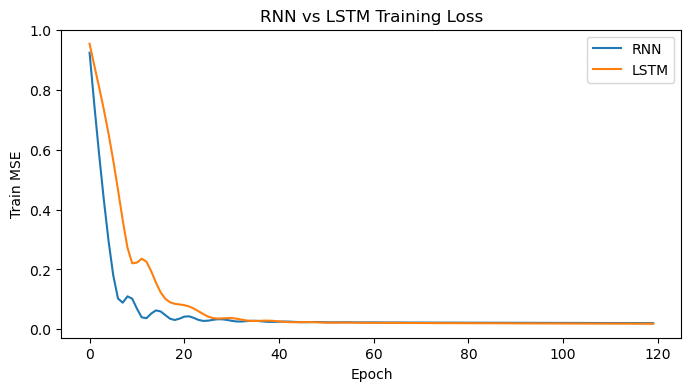

RNN final train loss: 0.020609023049473763
LSTM final train loss: 0.01867123506963253


In [26]:
torch.manual_seed(42)

rnn_model = RNNForecaster(
    hidden_size=16
).to(device)

rnn_losses = train_forecaster(
    rnn_model,
    X_train_seq,
    y_train_seq,
    epochs=120,
    lr=0.01
)

torch.manual_seed(42)

lstm_model = LSTMForecaster(
    hidden_size=16
).to(device)

lstm_losses = train_forecaster(
    lstm_model,
    X_train_seq,
    y_train_seq,
    epochs=120,
    lr=0.01
)

plt.figure(figsize=(8, 4))
plt.plot(rnn_losses, label="RNN")
plt.plot(lstm_losses, label="LSTM")
plt.xlabel("Epoch")
plt.ylabel("Train MSE")
plt.title("RNN vs LSTM Training Loss")
plt.legend()
plt.show()

print("RNN final train loss:", rnn_losses[-1])
print("LSTM final train loss:", lstm_losses[-1])

<div dir="rtl" style="text-align:right">

## תרגיל 6 — Hidden-State Heatmap של RNN

הציגו את ה־hidden states של דוגמת test אחת לאורך הזמן.

</div>

In [ ]:
# TODO:
# forward RNN with return_sequence=True
# transpose hidden sequence
# plot heatmap

<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
rnn_model.eval()

with torch.no_grad():
    (
        rnn_prediction,
        rnn_output,
        rnn_h_n
    ) = rnn_model(
        X_test_seq[0:1],
        return_sequence=True
    )

hidden_sequence = (
    rnn_output[0]
    .T
    .detach()
    .cpu()
    .numpy()
)

plt.figure(figsize=(9, 5))
plt.imshow(
    hidden_sequence,
    aspect="auto"
)
plt.xlabel("Time step")
plt.ylabel("Hidden unit")
plt.title("RNN Hidden-State Activity")
plt.colorbar()
plt.show()
```

</details>

<div dir="rtl" style="text-align:right">

# חלק ד׳ — LSTM

</div>

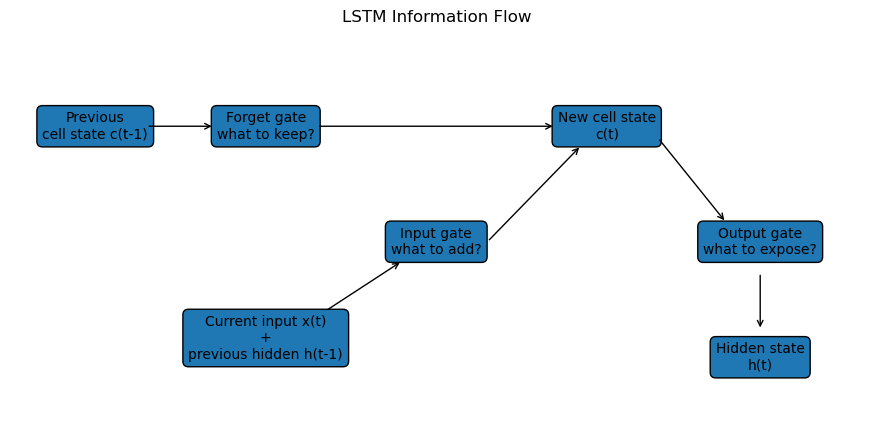

In [27]:
draw_lstm_gate_diagram()

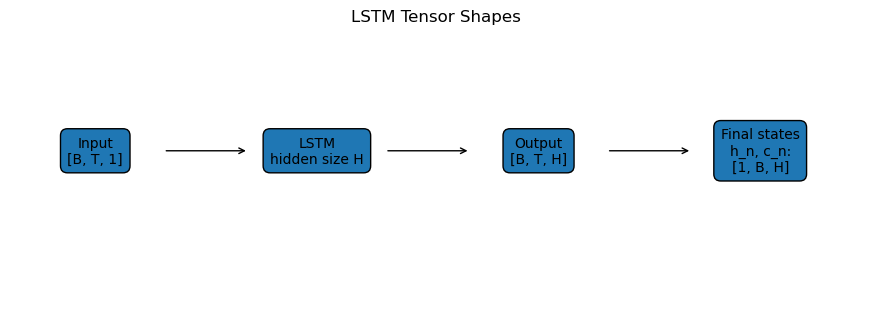

In [28]:
draw_lstm_shape_flow()

<div dir="rtl" style="text-align:right">

## תרגיל 7 — Shapes של LSTM

עבור batch של 4 דוגמאות, הדפיסו:

- input
- output
- `h_n`
- `c_n`
- prediction

</div>

In [29]:
# TODO:
# sample_batch = ...
# lstm_shape_model = ...
# forward with return_sequence=True
# print shapes
from sympy import python

sample_batch = X_train_seq[:4]

lstm_shape_model = LSTMForecaster(
    hidden_size=16
).to(device)

with torch.no_grad():
    (
        sample_prediction,
        sample_output,
        sample_h_n,
        sample_c_n
    ) = lstm_shape_model(
        sample_batch,
        return_sequence=True
    )

print("Input:", sample_batch.shape)
print("Output:", sample_output.shape)
print("h_n:", sample_h_n.shape)
print("c_n:", sample_c_n.shape)
print("Prediction:", sample_prediction.shape)


Input: torch.Size([4, 30, 1])
Output: torch.Size([4, 30, 16])
h_n: torch.Size([1, 4, 16])
c_n: torch.Size([1, 4, 16])
Prediction: torch.Size([4, 1])


<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
sample_batch = X_train_seq[:4]

lstm_shape_model = LSTMForecaster(
    hidden_size=16
).to(device)

with torch.no_grad():
    (
        sample_prediction,
        sample_output,
        sample_h_n,
        sample_c_n
    ) = lstm_shape_model(
        sample_batch,
        return_sequence=True
    )

print("Input:", sample_batch.shape)
print("Output:", sample_output.shape)
print("h_n:", sample_h_n.shape)
print("c_n:", sample_c_n.shape)
print("Prediction:", sample_prediction.shape)
```

</details>

<div dir="rtl" style="text-align:right">

# חלק ה׳ — Baselines והשוואת תחזיות

</div>

In [30]:
last_value_baseline_scaled = (
    X_test_seq[:, -1, 0]
    .detach()
    .cpu()
    .numpy()
)

mean_window_baseline_scaled = (
    X_test_seq[:, :, 0]
    .mean(dim=1)
    .detach()
    .cpu()
    .numpy()
)

actual_scaled = (
    y_test_seq[:, 0]
    .detach()
    .cpu()
    .numpy()
)

rnn_model.eval()
lstm_model.eval()

with torch.no_grad():
    rnn_predictions_scaled = (
        rnn_model(X_test_seq)
        .squeeze(1)
        .detach()
        .cpu()
        .numpy()
    )

    lstm_predictions_scaled = (
        lstm_model(X_test_seq)
        .squeeze(1)
        .detach()
        .cpu()
        .numpy()
    )

actual = inverse_scale(actual_scaled)

last_value_predictions = inverse_scale(
    last_value_baseline_scaled
)

mean_window_predictions = inverse_scale(
    mean_window_baseline_scaled
)

rnn_predictions = inverse_scale(
    rnn_predictions_scaled
)

lstm_predictions = inverse_scale(
    lstm_predictions_scaled
)

results = pd.DataFrame({
    "model": [
        "Last value",
        "Window mean",
        "RNN",
        "LSTM"
    ],
    "RMSE": [
        rmse(actual, last_value_predictions),
        rmse(actual, mean_window_predictions),
        rmse(actual, rnn_predictions),
        rmse(actual, lstm_predictions)
    ]
})

results

,model,RMSE
0,Last value,0.080941
1,Window mean,0.444093
2,RNN,0.070053
3,LSTM,0.069858
